# Notebook 01 — Environment Setup & TargetDiff Installation

**Goals of this notebook:**
1. Mount Google Drive and clone the project repo
2. Install all Python dependencies
3. Clone TargetDiff and download its pretrained checkpoint
4. Verify RDKit, PyTorch, and the `src/` module all work

**End state:** your Drive contains a complete `egfr_diffusion/` folder with code, TargetDiff, and the model checkpoint.  All subsequent notebooks start by running the same setup cell and can re-use this state.

⚠️ **Before running: set `REPO_URL` in the first code cell to your GitHub URL.**

## Step 1 — Mount Drive, clone repo, install deps

This cell runs every time you open any notebook; it's idempotent (safe to re-run).

In [2]:
import subprocess
subprocess.run(['git', '-C', '/content/drive/MyDrive/egfr_diffusion', 'pull'], check=True)

CompletedProcess(args=['git', '-C', '/content/drive/MyDrive/egfr_diffusion', 'pull'], returncode=0)

In [1]:
# EDIT THIS with your own GitHub repo URL
REPO_URL = "https://github.com/Jonathan-Ye-1/egfr-drug-design-eecs6895-final-project.git"

# First-run bootstrap: clone the repo so we can import src.colab_init
import os, subprocess
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

PROJECT_ROOT = '/content/drive/MyDrive/egfr_diffusion'
if not os.path.exists(os.path.join(PROJECT_ROOT, '.git')):
    subprocess.run(['git', 'clone', REPO_URL, PROJECT_ROOT], check=True)

import sys
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

# Now use the helper to finish setup (pull latest, install deps, make dirs)
from src.colab_init import setup
PROJECT_ROOT = setup(repo_url=REPO_URL)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
$ git pull
Already up to date.

Installing requirements (first run ~3-5 min)...

PROJECT_ROOT = /content/drive/MyDrive/egfr_diffusion


## Step 2 — Check GPU and package versions

In [2]:
import torch, rdkit, numpy, pandas
print('PyTorch :', torch.__version__, '| CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU     :', torch.cuda.get_device_name(0))
print('RDKit   :', rdkit.__version__)
print('NumPy   :', numpy.__version__)
print('Pandas  :', pandas.__version__)

# Important: if CUDA is False, go to Runtime → Change runtime type → GPU

PyTorch : 2.10.0+cpu | CUDA available: False
RDKit   : 2026.03.1
NumPy   : 2.0.2
Pandas  : 2.2.2


## Step 3 — Clone TargetDiff into Drive

In [3]:
import os, subprocess
targetdiff_dir = os.path.join(PROJECT_ROOT, 'external', 'targetdiff')
if not os.path.exists(targetdiff_dir):
    subprocess.run([
        'git', 'clone',
        'https://github.com/guanjq/targetdiff.git',
        targetdiff_dir
    ], check=True)
    print('TargetDiff cloned →', targetdiff_dir)
else:
    print('TargetDiff already present at', targetdiff_dir)

TargetDiff cloned → /content/drive/MyDrive/egfr_diffusion/external/targetdiff


## Step 4 — Download TargetDiff pretrained checkpoint

One-time download (~300 MB). Will live in Drive so all future notebooks re-use it.

In [4]:
import os
ckpt_dir = os.path.join(PROJECT_ROOT, 'external', 'targetdiff', 'checkpoints')
ckpt_path = os.path.join(ckpt_dir, 'pretrained_diffusion.pt')
os.makedirs(ckpt_dir, exist_ok=True)

if not os.path.exists(ckpt_path):
    !pip install -q gdown
    import gdown
    # Official TargetDiff checkpoint ID
    gdown.download(
        'https://drive.google.com/uc?id=1_BUWcHMQLbvOPbU4aYiDYcvF_0VEPjPZ',
        ckpt_path,
        quiet=False,
    )
else:
    size_mb = os.path.getsize(ckpt_path) / 1e6
    print(f'Checkpoint already present ({size_mb:.0f} MB) → {ckpt_path}')

FileURLRetrievalError: Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1_BUWcHMQLbvOPbU4aYiDYcvF_0VEPjPZ

but Gdown can't. Please check connections and permissions.

In [5]:
import os, subprocess
ckpt_dir = os.path.join(PROJECT_ROOT, 'external', 'targetdiff', 'checkpoints')
os.makedirs(ckpt_dir, exist_ok=True)

# Download the entire checkpoint folder from TargetDiff official
!pip install -q --upgrade gdown
!gdown --folder "https://drive.google.com/drive/folders/1-ftaIrTXjWFhw3-0Twkrs5m0yX6CNarz" -O "{ckpt_dir}"

# Show what was downloaded
print("\nFiles in checkpoints/:")
for f in os.listdir(ckpt_dir):
    size_mb = os.path.getsize(os.path.join(ckpt_dir, f)) / 1e6
    print(f"  {f}  ({size_mb:.0f} MB)")

Retrieving folder contents
Processing file 1hEcZstBWdC0KU8BLGpyQjQWeQb9huM_O egnn_pdbbind_v2016.pt
Processing file 1EUdea0CzkdZzOI0yTAyo3OOn1X_mbmJO pk_reg_para.pkl
Processing file 1DCbkVJ_Ib0tOD1QqNT1QYdzrVpZLeZQF pretrained_diffusion.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1hEcZstBWdC0KU8BLGpyQjQWeQb9huM_O
From (redirected): https://drive.google.com/uc?id=1hEcZstBWdC0KU8BLGpyQjQWeQb9huM_O&confirm=t&uuid=3038e3d9-a6a3-4258-bf2c-fffc1bb7a9b3
To: /content/drive/MyDrive/egfr_diffusion/external/targetdiff/checkpoints/egnn_pdbbind_v2016.pt
100% 30.6M/30.6M [00:00<00:00, 57.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1EUdea0CzkdZzOI0yTAyo3OOn1X_mbmJO
To: /content/drive/MyDrive/egfr_diffusion/external/targetdiff/checkpoints/pk_reg_para.pkl
100% 968/968 [00:00<00:00, 3.97MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1DCbkVJ_Ib

## Step 5 — Smoke test: RDKit + src module

Erlotinib QED = 0.726  (should be ~0.55)


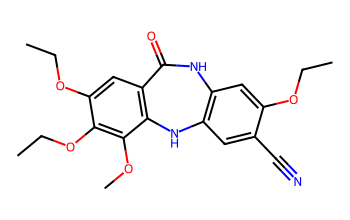


Targets configured: ['wildtype', 'mutant']
Baselines configured: ['erlotinib', 'gefitinib', 'osimertinib']

✅ Setup complete. You can now run notebook 02.


In [7]:
from rdkit import Chem
from rdkit.Chem import QED, Draw
from IPython.display import display

mol = Chem.MolFromSmiles('C(#N)c1cc2c(cc1OCC)NC(=O)c1cc(OCC)c(OCC)c(OC)c1N2')  # Erlotinib
print(f'Erlotinib QED = {QED.qed(mol):.3f}  (should be ~0.55)')
display(Draw.MolToImage(mol, size=(350, 220)))

from src.evaluation import MolEvaluator
from src.utils import load_config
cfg = load_config('configs/targets.yaml')
print('\nTargets configured:', list(cfg['targets'].keys()))
print('Baselines configured:', list(cfg['baselines'].keys()))
print('\n✅ Setup complete. You can now run notebook 02.')

## What got saved to Drive

After this notebook finishes, your `/content/drive/MyDrive/egfr_diffusion/` contains:

```
egfr_diffusion/
├── src/  configs/  notebooks/    ← from GitHub
├── data/                         ← empty, ready for notebook 02
├── results/                      ← empty, ready for later notebooks
└── external/targetdiff/
    └── checkpoints/pretrained_diffusion.pt  ← ~300 MB
```

Close this notebook. Next time you open any notebook (02, 03, …), you only need to run its **first cell** (Step 1 above) — everything else is already in Drive.